## CosmicFish v1.0

In [1]:
#Importing main module
from cosmicfishpie.fishermatrix import cosmicfish
import numpy as np
import os

In [2]:
envkey = 'OMP_NUM_THREADS'
# Set this environment variable to the number of available cores in your machine, 
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(8)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  8


## CosmicFish in all modes

In [3]:
lss_fish_dic = dict()

## EXT

In [4]:
external = {'directory': '/media/santiago/SecondDisk/Euclid-Files/w0wafiles/default_camb_euclid_w0wa_HP/',  ## Files should be in the input4cast format
            'paramnames': ['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0','wa'],  ## Certain paramnames like Omegam and h are obligatory
            'folder_paramnames': ['Om', 'Ob', 'h', 'ns', 's8', 'w0', 'wa'],   ## Folder paramnames can have different names as paramnames
            'file_prefixes' : ['background_Hz','D_Growth-zk',  
                               'f_GrowthRate-zk', 'Plin-zk',    ## Names of cosmological quantity files can be specified here
                               'Pnonlin-zk', 'sigma8-z'],
            'k-units' : 'h/Mpc',   ## Units of the external input files
            'r-units' : 'Mpc',      
            'eps_values': [0.00625, 0.01, 0.0125, 0.01875, 0.025, 0.03, 0.0375, 0.05, 0.10]   ## Epsilon parameter variations at which files were computed
            } 

fiducial = {"Omegam":0.32,
            "Omegab":0.05,
            "h":0.67,
            "ns":0.96,          ## Fiducial values of the cosmological parameters
            "sigma8":0.815584,
            "w0":-1.0,
            "wa":0.
            }
## Fiducial values of the nuisance parameters are set by default when specifying the survey below. Can be added also manually.
freepars = {"Omegam":0.01,
            "Omegab":0.01 ,
            "h":0.01,           
            "ns":0.01,        ## If derivatives are calculated with 3PT, this sets the epsilon step size, per parameter. 
            "sigma8":0.01,      ## Should match one of the epsilons available above
            "w0":0.01,
            "wa":0.01
            } 

#specifications = ['ISTF-Optimistic', 'DR1-forza']
specifications = ['ISTF-Pessimistic', 'DR1-debole']
cosmoFM = dict()
for specif in specifications:
    options = {
           #'derivatives': '4PT_FWD',      ## Derivative option: 3PT or SteM
           'derivatives': '3PT',      ## Derivative option: 3PT or SteM
           'accuracy': 1,
           'feedback': 2,
           'code': 'external',
           'outroot': 'DR1-3-w0waCDM-{:s}-ext-'.format(specif),    #String attached to all the results files
           'results_dir' :  './results/',
           'specs_dir' : '../survey_specifications/',     
           'survey_name_photo': 'Euclid-Photometric-'+specif,
           'survey_name_spectro': 'Euclid-Spectroscopic-'+specif,
           'cosmo_model' : 'w0waCDM',
           'activateMG': False}
    observables = [['GCsp']]#['WL', 'GCph']]
    for obse in observables:              
    #Observables for which to compute the Fisher
        savekey = specif+str(obse) 
        cosmoFM[savekey] = cosmicfish.FisherMatrix(fiducialpars=fiducial,    #Pass the above dictionaries to cosmoFM, the main cosmicfish class
                                  freepars=freepars,
                                  options=options, 
                                  observables=obse, 
                                  extfiles=external, 
                                  cosmoModel=options['cosmo_model']
                                  )
                                
        lss_fish_dic[options['outroot']] = cosmoFM[savekey].compute()    # Compute the Fisher Matrix

**************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

**************************************************************
 This is the new Python version of the CosmicFish code.
**************************************************************
Using input files for cosmology observables.
External directory:  /media/santiago/SecondDisk/Euclid-Files/w0wafiles/default_camb_euclid_w0wa_HP/
20 subfolders for parameter Om
External directory:  /media/santiago/SecondDisk/Euclid-Files/w0wafiles/default_camb_euclid_w0wa_HP/
20 subfolders for parameter Ob
External directory:  /media/santiago/SecondDisk/Euclid-Files/w0wafiles/default_camb_euclid_w0wa_HP/
20 subfolders for parameter h
External directory:  /media/santiago/SecondDisk/Euclid-Files/w0wafiles/default_camb_euclid_w0wa_HP/
20 subfolders for parameter ns
External d

KeyboardInterrupt: 

In [5]:
istk = list(cosmoFM.keys())[0]
print(istk)

ISTF-Pessimistic['GCsp']


In [6]:
cosmoFM[istk].pk_cov.area_survey

15000.000000000002

In [7]:
"{:.3E}".format(cosmoFM[istk].pk_cov.volume_survey(0))

'2.639E+10'

In [8]:
"{:.3E}".format(cosmoFM[istk].pk_cov.cov(1, 0.1, 0.5))


    Computing Pgg for ['GCsp']

In class: ComputeGalSpectro  observed P_gg computation took:   0.00 s

    Computing Pgg for ['GCsp']

In class: ComputeGalSpectro  observed P_gg computation took:   0.00 s


'3.423E+05'

In [9]:
"{:.3E}".format(cosmoFM[istk].pk_cov.veff(1, 0.1, 0.5))


    Computing Pgg for ['GCsp']

In class: ComputeGalSpectro  observed P_gg computation took:   0.00 s


'5.100E-03'

In [12]:
"{:.3E}".format(cosmoFM[istk].pk_cov.n_density(0))

'2.064E-04'

In [13]:
cosmoFM[istk].pk_cov.dnz

array([1815.  , 1701.5 , 1410.  ,  940.97])

In [14]:
cosmoFM[istk].pk_cov.dz_bins

array([0.2, 0.2, 0.2, 0.3])

In [15]:
"{:.3E}".format(cosmoFM[istk].pk_cov.d_volume(0))

'7.257E+10'

In [16]:
"{:.3E}".format(cosmoFM[istk].pk_cov.volume_bin(0.9, 1.1))

'7.257E+10'

## Plot the resulting Fisher matrices

In [4]:
from cosmicfishpie.analysis import fisher_plotting as fpp
from cosmicfishpie.analysis import fisher_matrix as fm
from cosmicfishpie.analysis import fisher_operations as fo
import glob
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('../scripts/plot-style.txt')
import seaborn as sns
snscolors=sns.color_palette("Set2")
snscolors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [5]:
filenames = glob.glob('./results/*CosmicFish*w0waCDM*ext-_*fishermatrix*.txt')
filenames

['./results/CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WLGCph_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_WLGCph_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-DR1-debole-ext-_WLGCph_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-DR1-debole-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WLGCph_fishermatrix.txt']

In [6]:
filenames = [filenames[ii] for ii in [2, 3, 5, 7]]

In [7]:
filenames

['./results/CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix.txt',
 './results/CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix.txt']

In [8]:
Fishes = [fm.fisher_matrix(file_name=file) for file in filenames]
for ffi in Fishes:
    print(ffi.name)
    print(ffi.get_param_names())

CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix
['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa', 'lnbgs8_1', 'lnbgs8_2', 'lnbgs8_3', 'lnbgs8_4', 'Ps_1', 'Ps_2', 'Ps_3', 'Ps_4']
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix
['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa', 'AIA', 'betaIA', 'etaIA']
CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix
['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa', 'AIA', 'betaIA', 'etaIA']
CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix
['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa', 'lnbgs8_1', 'lnbgs8_2', 'lnbgs8_3', 'lnbgs8_4', 'Ps_1', 'Ps_2', 'Ps_3', 'Ps_4']


In [9]:
fishEucCombDR1 = Fishes[0]+Fishes[1]
fishEucCombISTF = Fishes[2]+Fishes[3]
Fishes.append(fishEucCombDR1)
Fishes.append(fishEucCombISTF)

In [10]:
for ii, fish in enumerate(Fishes):
    print("Fisher Name: ", fish.name)
    sigmas = fish.get_confidence_bounds()
    fidus = fish.get_param_fiducial()
    parnames = fish.get_param_names()
    fiww = fo.marginalise(fish, ['w0','wa'])
    deFoM = np.sqrt(fiww.determinant())
    print("Fisher DE FoM: ", deFoM)
    for ii, par in enumerate(parnames):
        print("Parameter {:s},  fiducial: {:.3f}, 1-sigma error: {:.4f}, percent error: {:.1f}%".format(
            par, fidus[ii], abs(sigmas[ii]), abs(100*sigmas[ii]/fidus[ii])))

Fisher Name:  CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix
Fisher DE FoM:  5.110779800791994
Parameter Omegam,  fiducial: 0.320, 1-sigma error: 0.0555, percent error: 17.3%
Parameter Omegab,  fiducial: 0.050, 1-sigma error: 0.0098, percent error: 19.7%
Parameter h,  fiducial: 0.670, 1-sigma error: 0.0932, percent error: 13.9%
Parameter ns,  fiducial: 0.960, 1-sigma error: 0.0609, percent error: 6.3%
Parameter sigma8,  fiducial: 0.816, 1-sigma error: 0.0540, percent error: 6.6%
Parameter w0,  fiducial: -1.000, 1-sigma error: 0.4835, percent error: 48.3%
Parameter wa,  fiducial: 0.000, 1-sigma error: 1.3670, percent error: inf%
Parameter lnbgs8_1,  fiducial: -0.325, 1-sigma error: 0.0634, percent error: 19.5%
Parameter lnbgs8_2,  fiducial: -0.316, 1-sigma error: 0.0634, percent error: 20.1%
Parameter lnbgs8_3,  fiducial: -0.312, 1-sigma error: 0.0630, percent error: 20.2%
Parameter lnbgs8_4,  fiducial: -0.320, 1-sigma error: 0.0623, percent error: 19.4%
Parameter Ps_1,

/tmp/ipykernel_3502848/1192934749.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  par, fidus[ii], abs(sigmas[ii]), abs(100*sigmas[ii]/fidus[ii])))


In [11]:
for fi in Fishes:
    print(fi.name)

CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix_CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix_CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix


In [12]:
plotPars = (Fishes[0].param_names)[:7]
print(plotPars)

['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa']


In [13]:
plotFishes = Fishes
#plotFishnames = ['CosmicFish-w0waCDM-3x2ph-DR1-debole-order1', 'CosmicFish-w0waCDM-3x2ph-IST:F_pess']
plotFishnames = [
                 'CosmicFish-w0waCDM-DR1-debole-o1-GCsp', 
                 'CosmicFish-w0waCDM-DR1-debole-o1-WL', 
                 'CosmicFish-w0waCDM-IST:F_pess-WL',
                 'CosmicFish-w0waCDM-IST:F_pess-GCsp',
                 'CosmicFish-w0waCDM-DR1-debole-o1-WL+GCsp',
                 'CosmicFish-w0waCDM-IST:F_pess-WL+GCsp',
                 ]
print(plotFishnames)
[print(fi.name) for fi in plotFishes];

['CosmicFish-w0waCDM-DR1-debole-o1-GCsp', 'CosmicFish-w0waCDM-DR1-debole-o1-WL', 'CosmicFish-w0waCDM-IST:F_pess-WL', 'CosmicFish-w0waCDM-IST:F_pess-GCsp', 'CosmicFish-w0waCDM-DR1-debole-o1-WL+GCsp', 'CosmicFish-w0waCDM-IST:F_pess-WL+GCsp']
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_GCsp_fishermatrix_CosmicFish_v1.0_DR1-3-w0waCDM-DR1-debole-ext-_WL_fishermatrix
CosmicFish_v1.0_DR1-3-w0waCDM-Photometric-ISTF-Pessimistic-ext-_WL_fishermatrix_CosmicFish_v1.0_DR1-3-w0waCDM-ISTF-Pessimistic-ext-_GCsp_fishermatrix


./plots  exists already
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-DR1-debole-o1-GCsp
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-DR1-debole-o1-WL
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-IST:F_pess-WL
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-IST:F_pess-GCsp
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-DR1-debole-o1-WL+GCsp
Fisher matrix loaded, label name:  CosmicFish-w0waCDM-IST:F_pess-WL+GCsp
('Fishers names: ', ['CosmicFish-w0waCDM-DR1-debole-o1-GCsp', 'CosmicFish-w0waCDM-DR1-debole-o1-WL', 'CosmicFish-w0waCDM-IST:F_pess-WL', 'CosmicFish-w0waCDM-IST:F_pess-GCsp', 'CosmicFish-w0waCDM-DR1-debole-o1-WL+GCsp', 'CosmicFish-w0waCDM-IST:F_pess-WL+GCsp'])
('parameters to plot: ', ['Omegam', 'Omegab', 'h', 'ns', 'sigma8', 'w0', 'wa'])
X tick labels ---> :   ['\\Omega_{{\\rm m}, 0}', '\\Omega_{{\\rm b}, 0}', 'h', 'n_{\\rm s}', '\\sigma_8', 'w_0', 'w_a']


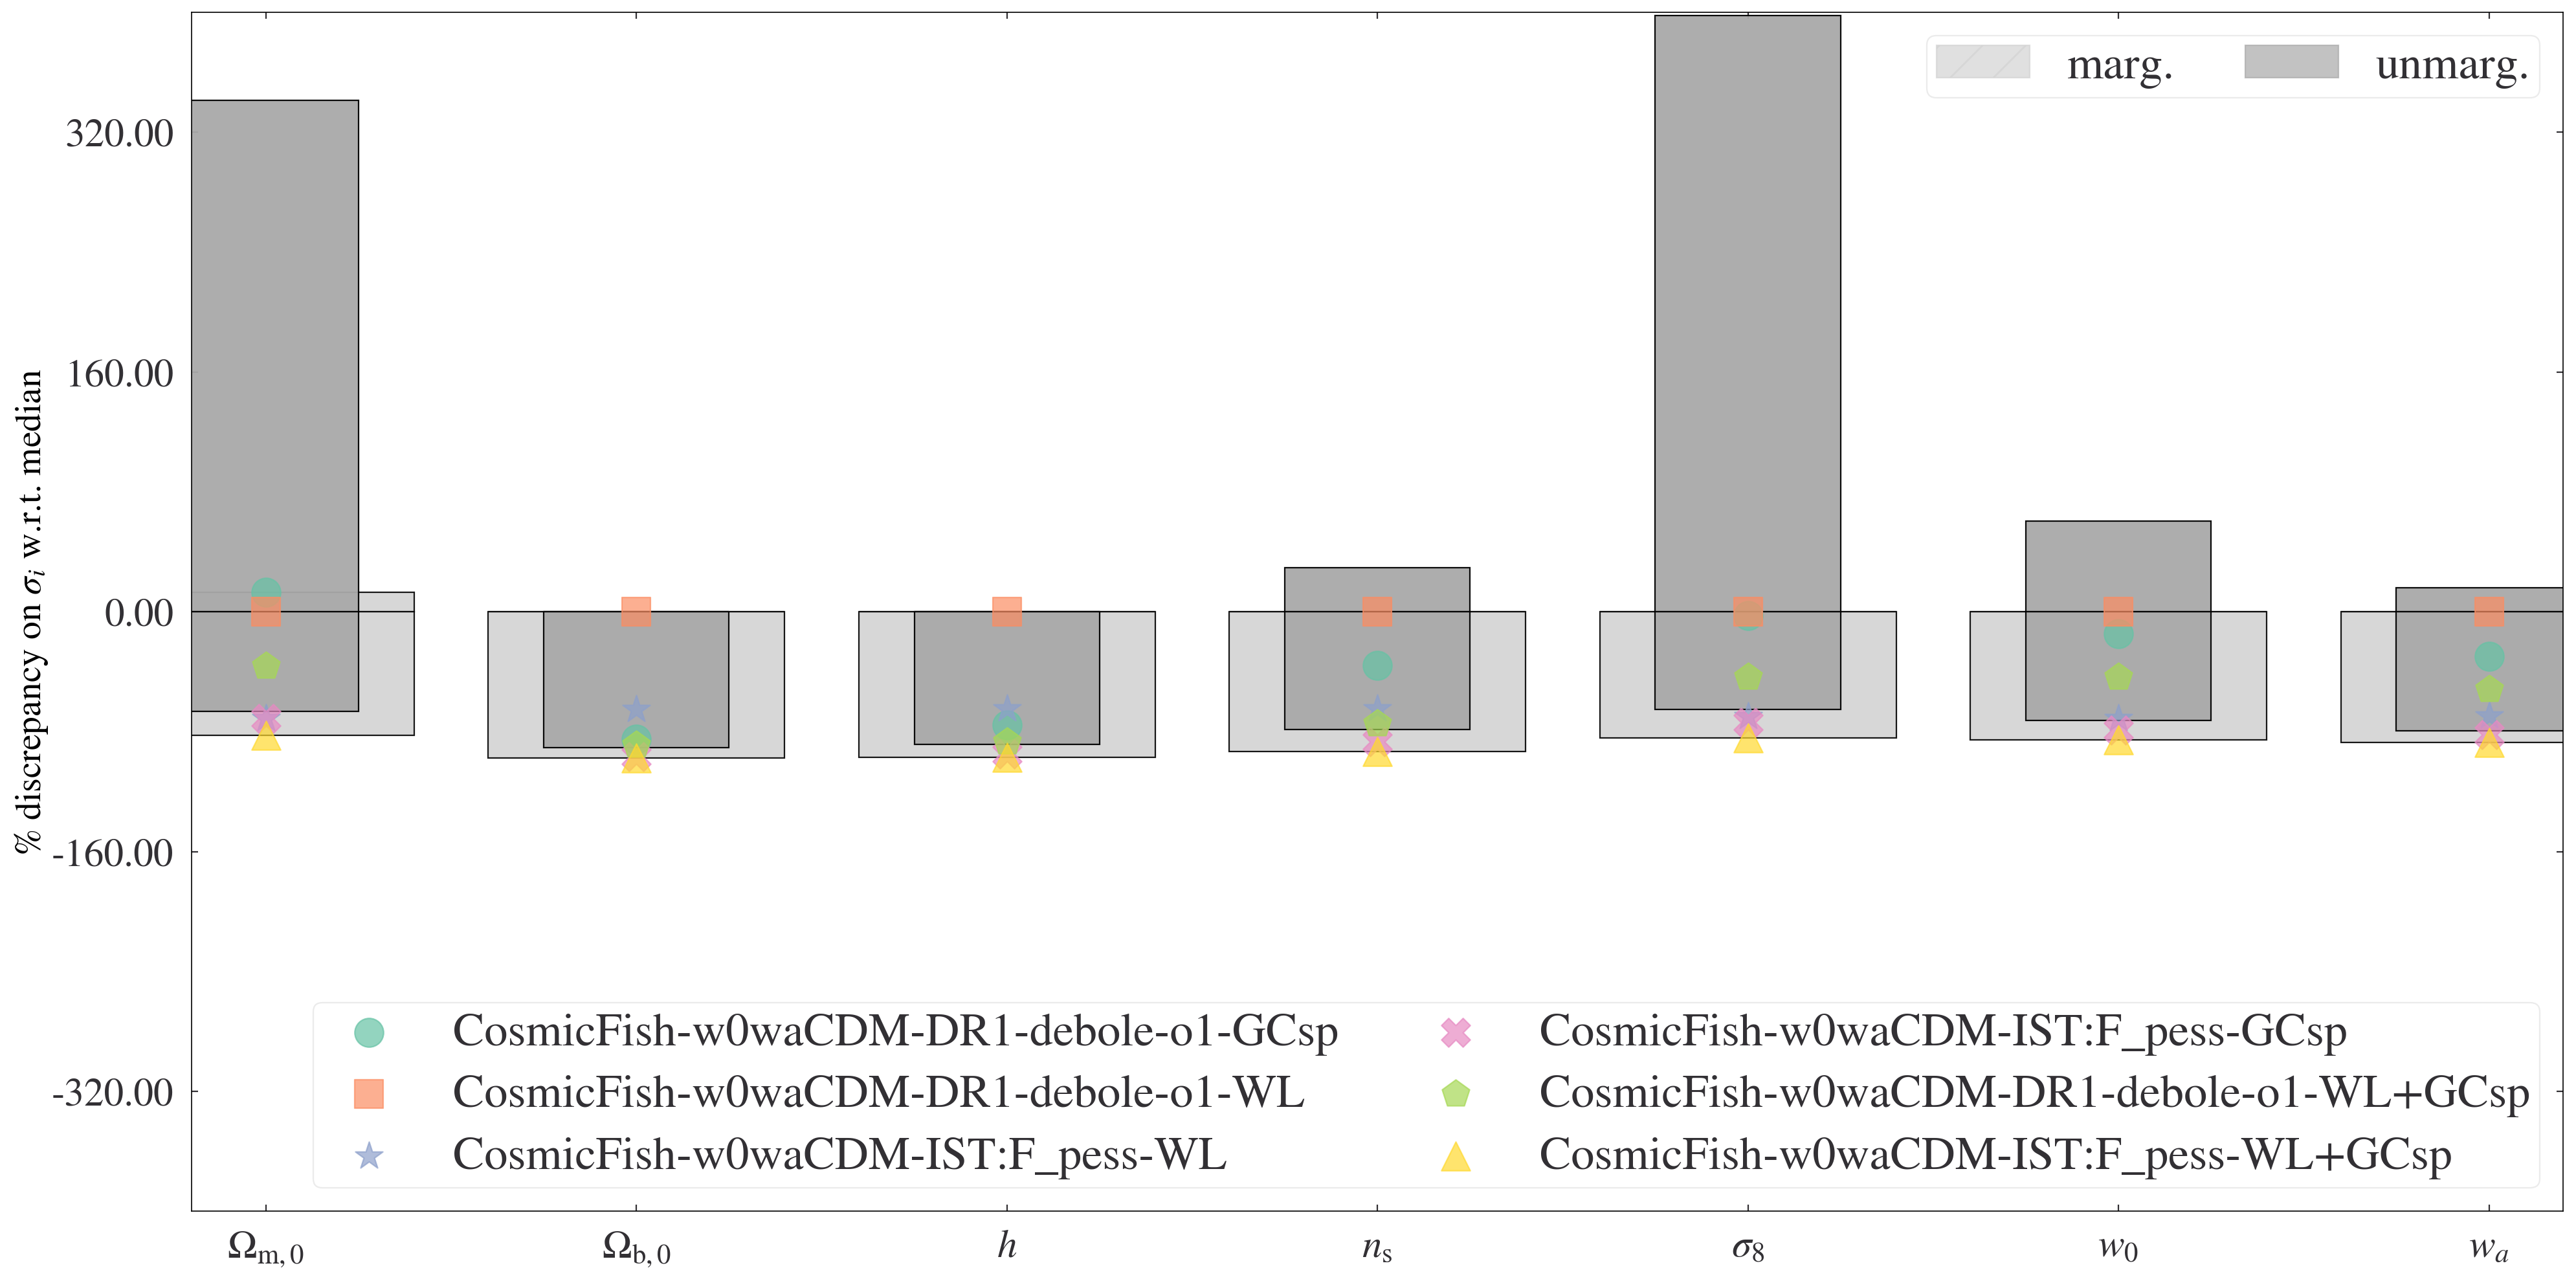

In [14]:
plot_options = {'fishers_list': plotFishes,
          'colors': snscolors,
          'fish_labels' : plotFishnames,
          'plot_pars': plotPars,
          'axis_custom_factors': {'all': 3},  ## Axis limits cover 3-sigma bounds of first Fisher matrix
          'plot_method': 'Gaussian',
          'file_format': '.pdf',   ##file format for all the plots
          'outpath' : './plots/',  ## directory where to store the files, if non-existent, it will be created
          'outroot':'CF-WL+GCsp-pess'  ## file name root for all the plots, extra names can be added individually
          } 
fish_plotter = fpp.fisher_plotting(**plot_options)
fish_plotter.load_gaussians()
#fish_plotter.plot_fisher(filled=False, contour_args=[{'alpha':0.99, 'ls': '--'}, {'alpha':0.85, 'ls': '--'}])
fish_plotter.compare_errors(options={'ncol_legend': 2, 'yrang': [-400, 400], 'compare_to_index':1})

Entering plotting routine
{'Omegam': [0.15362104924407588, 0.48637895075592413], 'Omegab': [0.020457527768246803, 0.0795424722317532], 'h': [0.39027150412031386, 0.9497284958796862], 'ns': [0.7773921072721967, 1.1426078927278032], 'sigma8': [0.6535506655183609, 0.977617334481639], 'w0': [-2.4504893640823466, 0.45048936408234685], 'wa': [-4.101078663442857, 4.101078663442857], 'lnbgs8_1': [-0.45224086498259375, -0.1985991350174062], 'lnbgs8_2': [-0.4426206345207243, -0.18919336547927565], 'lnbgs8_3': [-0.43747590650836377, -0.18559809349163625], 'lnbgs8_4': [-0.4447163118959839, -0.19563968810401616], 'Ps_1': [-907.4145838320343, 907.4145838320343], 'Ps_2': [-900.9098513558027, 900.9098513558027], 'Ps_3': [-914.5590863569619, 914.5590863569619], 'Ps_4': [-881.5145326547886, 881.5145326547886]}


/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/analysis/fisher_plotting.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  g.fig.savefig(
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


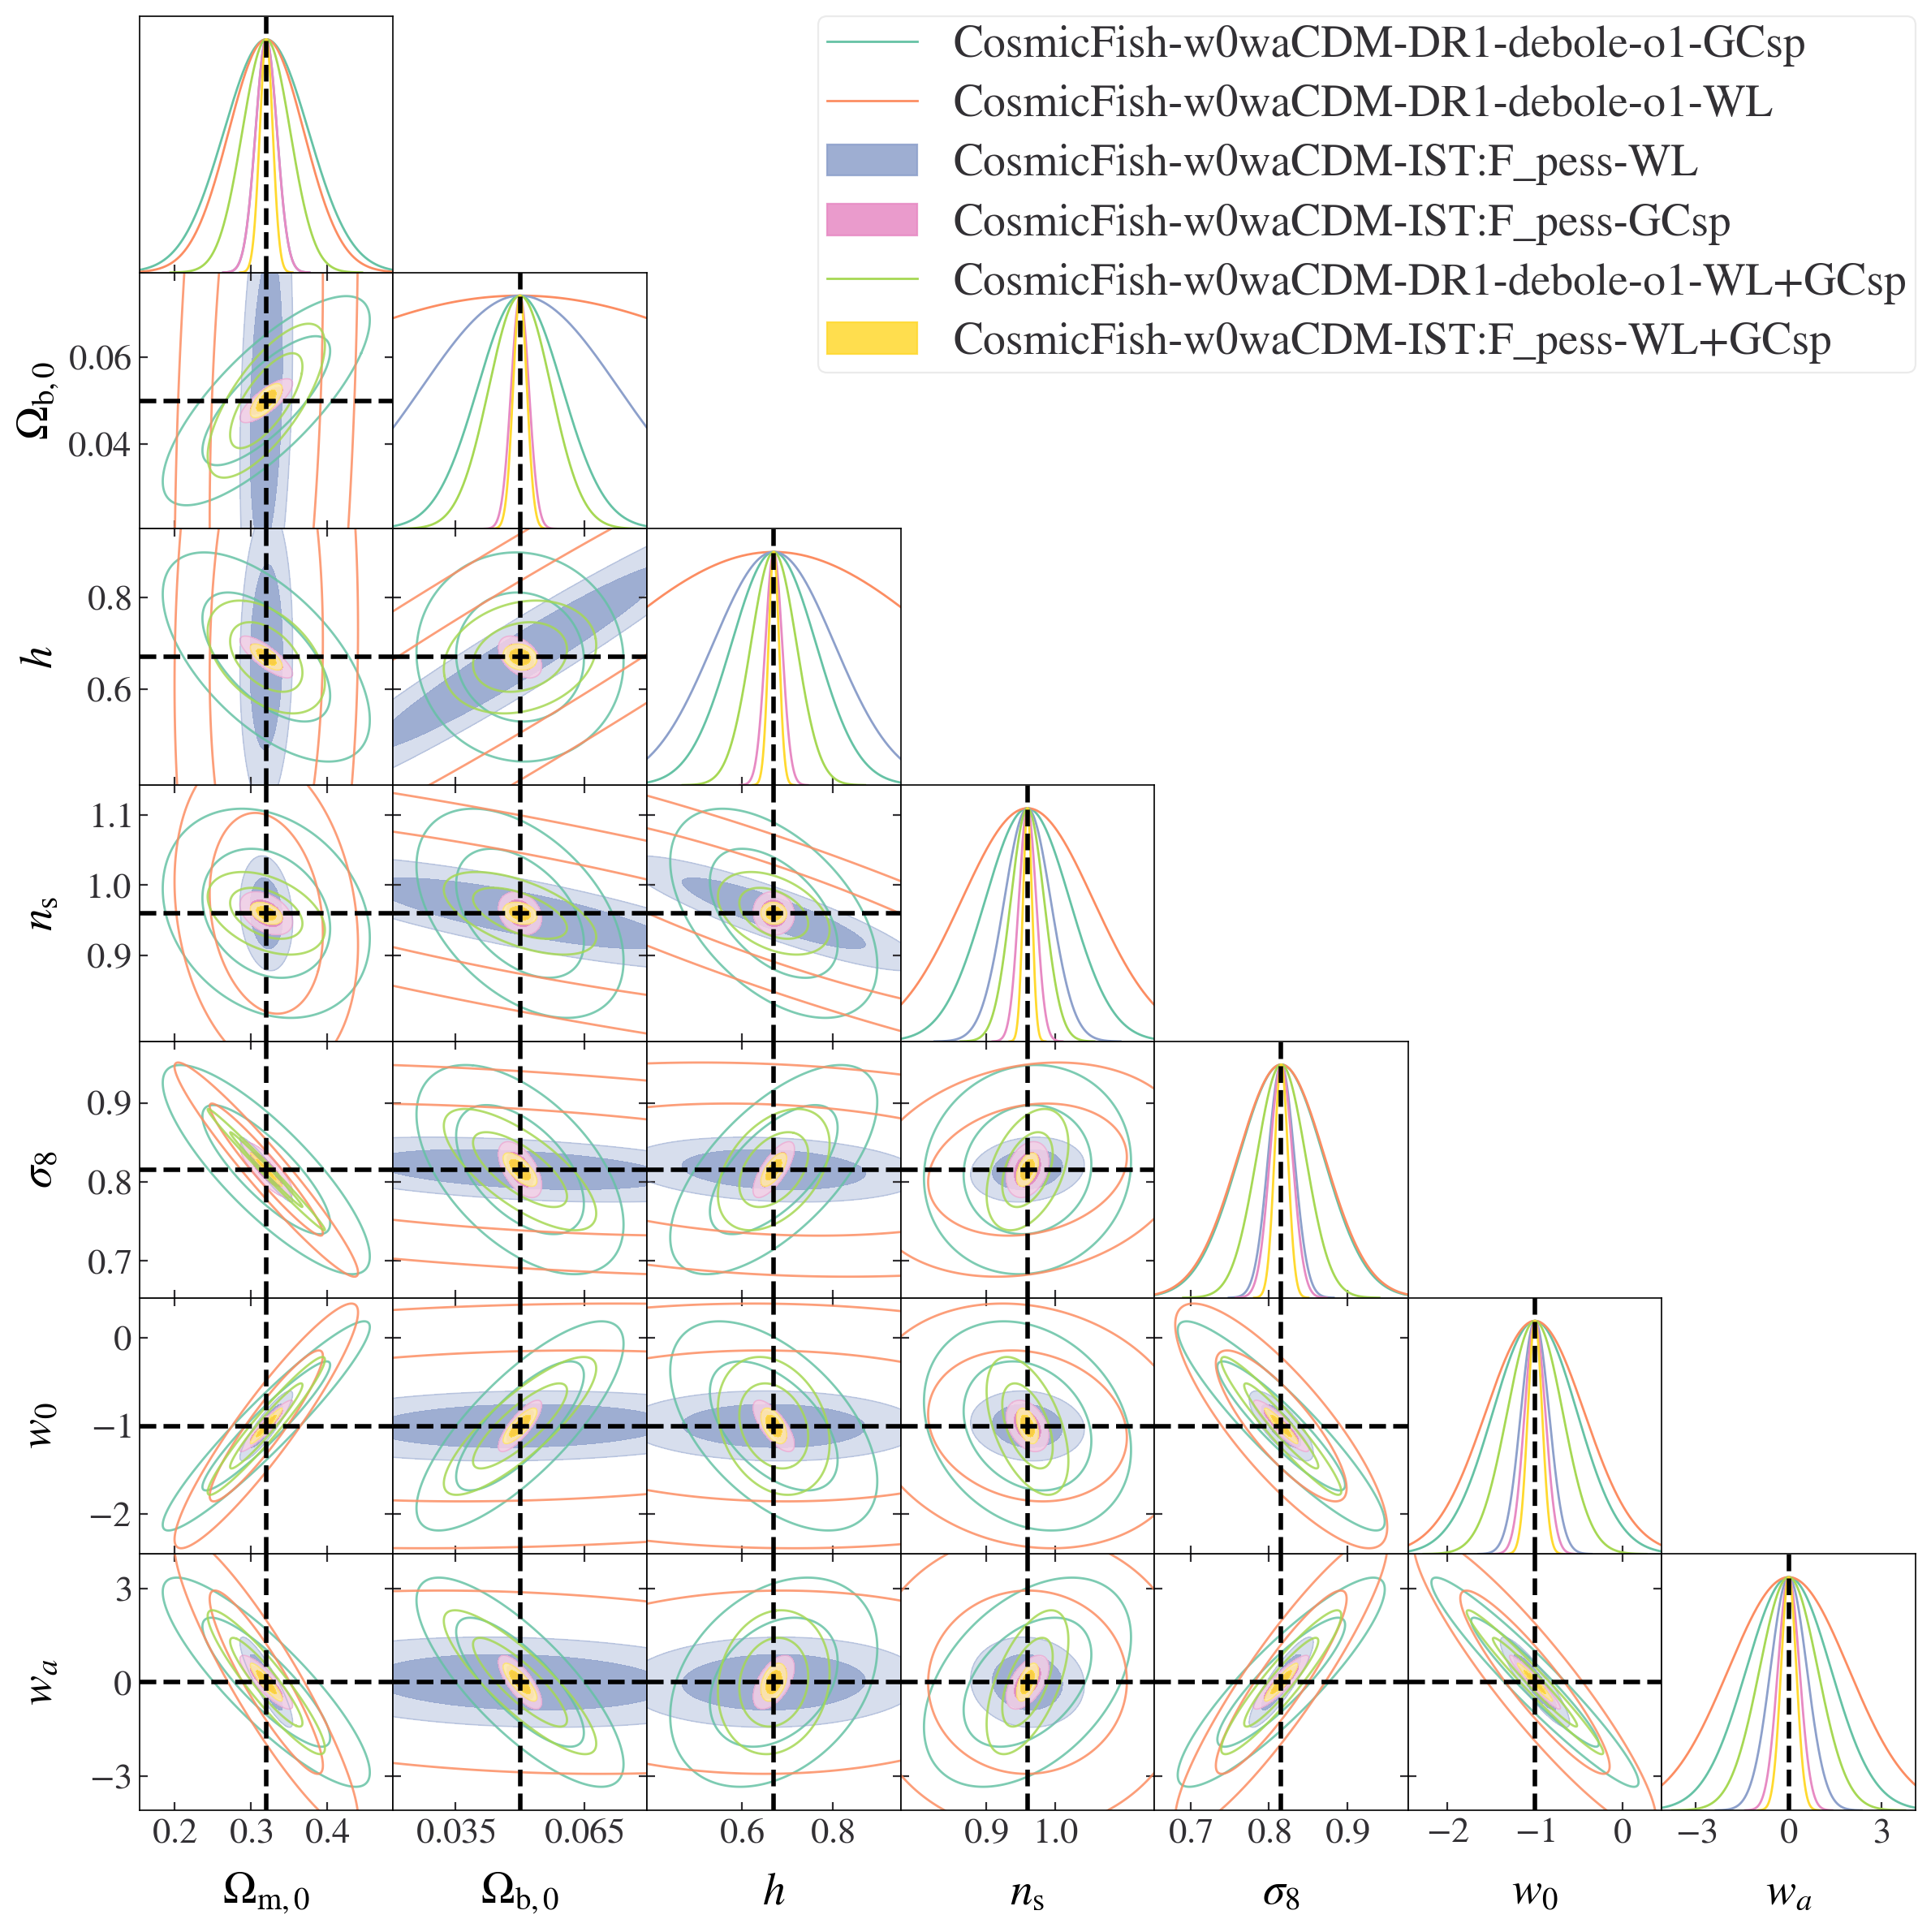

In [15]:
fish_plotter.plot_fisher(filled=[False,False,True,True,False,True], 
                          contour_args=[{'alpha':0.85, 'ls': '-'},  
                                        {'alpha':0.85, 'ls': '-'},
                                        {'alpha':0.85, 'ls': '-'},
                                        {'alpha':0.85, 'ls': '-'},
                                        {'alpha':0.85, 'ls': '-'},
                                        {'alpha':0.85, 'ls': '-'}
                                        ])